/tmp/ipython-input-678600219.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  MSCI_prices = pd.read_csv("/content/MSCI returns.csv", parse_dates=['Date'], thousands=',')
/tmp/ipython-input-678600219.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  MSCI_dividends = pd.read_csv("/content/MSCI dividends.csv", parse_dates=['date'], thousands=',')
/tmp/ipython-input-678600219.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  FX_returns = pd.read_csv("/content/FX returns.csv", parse_dates=['date'], thousands=',')



--- FULL PERIOD (Uniform) ---
Optimal Portfolio - Sharpe Ratio (RF=0%): 0.7076
Optimal Portfolio - Expected Return: 0.1064
Optimal Portfolio - Volatility: 0.1504

Optimal Portfolio - Sharpe Ratio (RF=4%): 0.4416
Optimal Portfolio - Expected Return: 0.1064
Optimal Portfolio - Volatility: 0.1504

MSCI USA - Sharpe (RF=0%): 0.7174
MSCI USA - Sharpe (RF=4%): 0.4633
MSCI USA - Expected Return: 0.1129
MSCI USA - Volatility: 0.1574

Optimal Portfolio Weights (RF = 0%):
                            Index    Weight
5  msci switzerland - price index  0.264570
8          msci usa - price index  0.259686
2       msci canada - price index  0.236060
0    msci australia - price index  0.073385
1       msci brazil - price index  0.039940
4        msci japan - price index  0.038650
6       msci turkey - price index  0.035738
7           msci uk - price index  0.034644
3      msci germany - price index  0.017328

Optimal Portfolio Weights (RF = 4%):
                            Index    Weight
5  msci sw

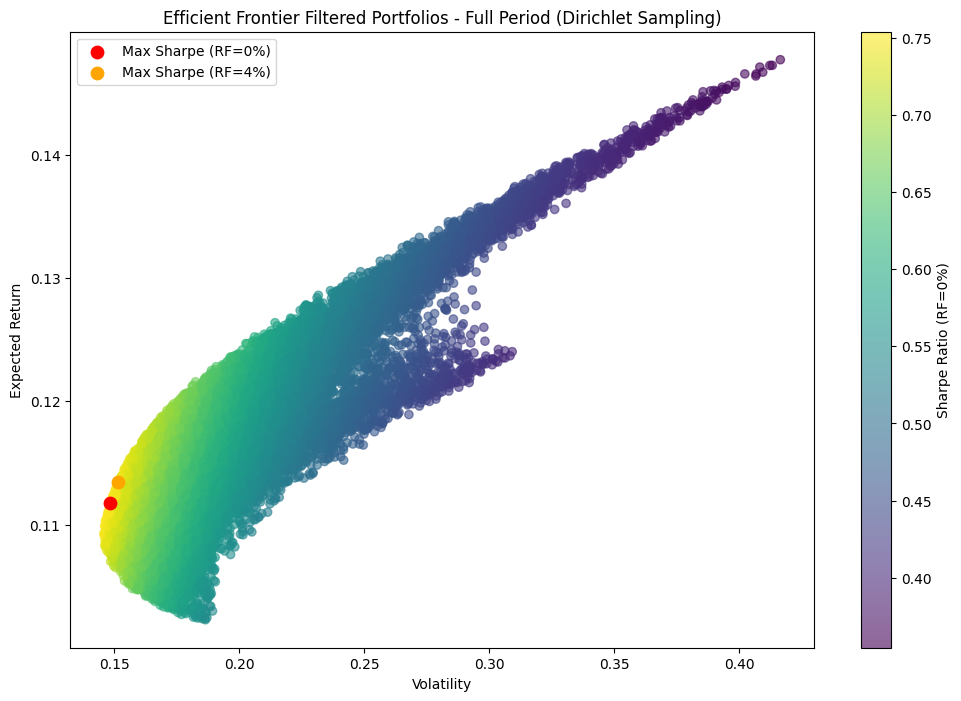

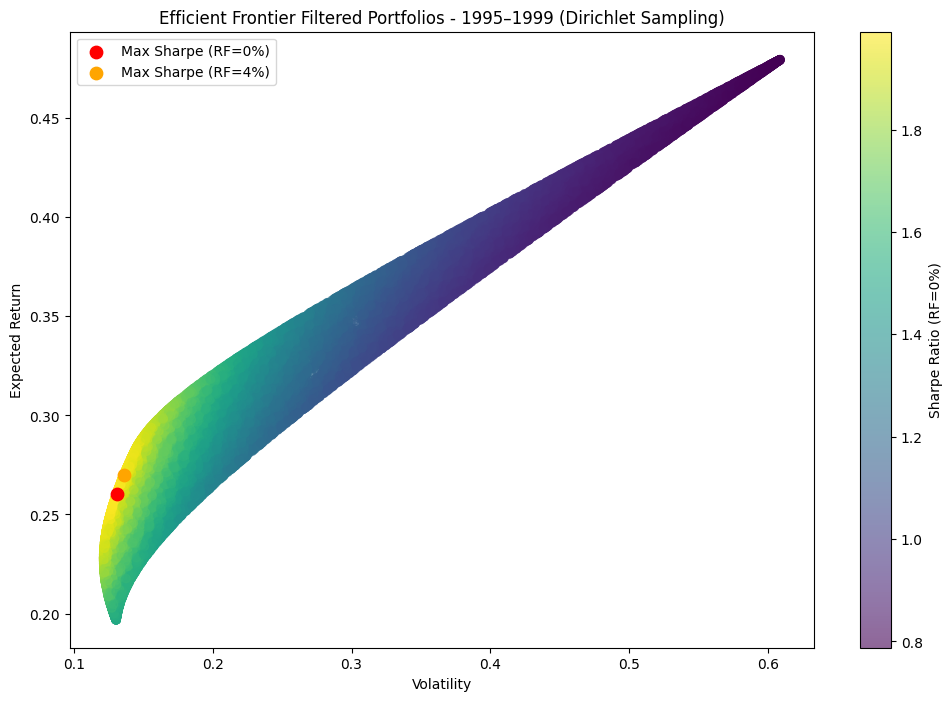

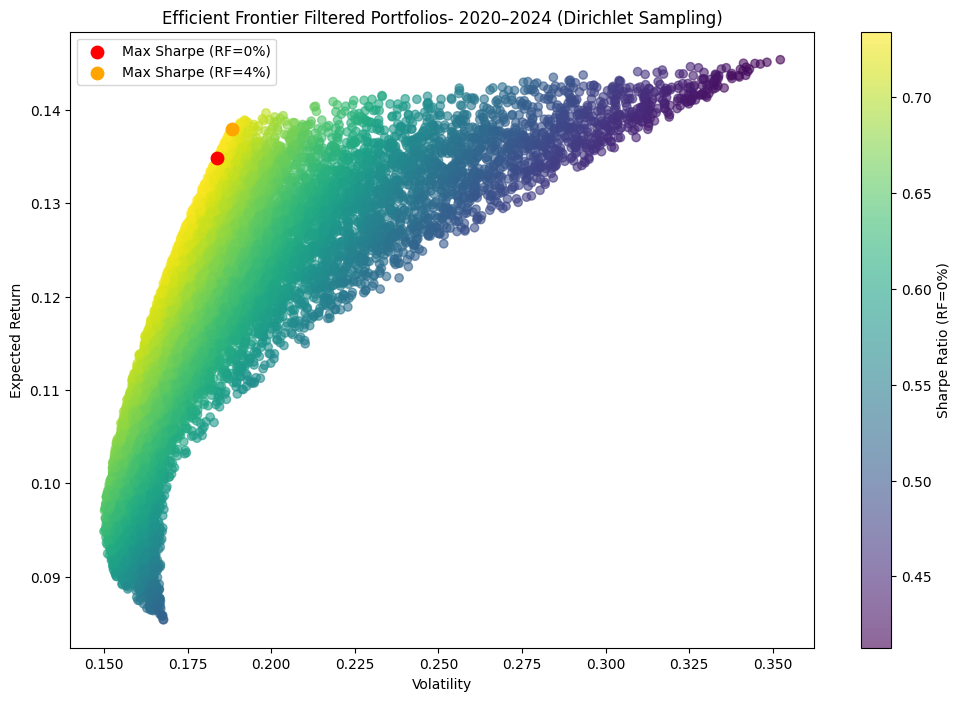

In [ ]:
"""
This script:
1. Loads MSCI price, dividend yield, and FX data.
2. Converts local index returns to USD returns (including dividends and FX effects).
3. Runs Monte Carlo simulations (uniform & Dirichlet sampling) to find optimal portfolios.
4. Computes key portfolio and index-level statistics (Sharpe, correlations, hurdle rates).
5. Filters out indexes below a calculated hurdle rate and re-runs the optimization.
6. Compares unfiltered vs filtered optimal portfolios to MSCI USA benchmark.
7. Visualizes the frontier of filtered investable universe under the hurdle rate requirement.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# === Loading & preprocessing data ===

# Creating 3 dataframes one for MSCI indexes prices, one for MSCI indexes annualised dividends, and one for FX returns of the corresponding currencies
MSCI_prices = pd.read_csv("/content/MSCI returns.csv", parse_dates=['Date'], thousands=',')
MSCI_dividends = pd.read_csv("/content/MSCI dividends.csv", parse_dates=['date'], thousands=',')
FX_returns = pd.read_csv("/content/FX returns.csv", parse_dates=['date'], thousands=',')

# Slicing the dataframe to get only the desired data
MSCI_prices = MSCI_prices.iloc[:, :10]
MSCI_dividends = MSCI_dividends.iloc[:, :10]
FX_returns = FX_returns.iloc[:, :10]

# Standardizing column names of dataframes
MSCI_prices.columns = MSCI_prices.columns.str.lower()
MSCI_dividends.columns = MSCI_dividends.columns.str.lower()
FX_returns.columns = FX_returns.columns.str.lower()

# Standardizing the format of the dataframes
MSCI_prices['date'] = pd.to_datetime(MSCI_prices['date'], format='%Y.%m')
MSCI_dividends['date'] = pd.to_datetime(MSCI_dividends['date'], format='%Y.%m')
FX_returns['date'] = pd.to_datetime(FX_returns['date'], format='%Y.%m')

# Converting data columns to numeric
MSCI_prices.iloc[:, 1:] = MSCI_prices.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
MSCI_dividends.iloc[:, 1:] = MSCI_dividends.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
FX_returns.iloc[:, 1:] = FX_returns.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# Fixing incorrect October dates in datasets (custom correction logic)
def fix_october_dates(date_series):
    fixed_dates = []
    prev_month = None

    for date in date_series:
        # If the month is January (1), we need to infer if it should be October (10)
        if date.month == 1:
            # If the previous month was September (9), we assume it's October (10)
            if prev_month == 9:
                fixed_dates.append(date.replace(month=10))
            else:
                # Otherwise, it's correct as January
                fixed_dates.append(date)
        else:
            # For all other months, keep the date without a change
            fixed_dates.append(date)
        # Update the previous month
        prev_month = date.month

    return fixed_dates

# Setting Date as the index
MSCI_prices.set_index('date', inplace=True)
MSCI_dividends.set_index('date', inplace=True)
FX_returns.set_index('date', inplace=True)

# Applying the function to fix October dates
MSCI_prices.index = fix_october_dates(MSCI_prices.index)
MSCI_dividends.index = fix_october_dates(MSCI_dividends.index)
FX_returns.index = fix_october_dates(FX_returns.index)

MSCI_dividends.columns = MSCI_prices.columns


# === Calculating USD returns ===

# Calculating percentage change for FX rates (FX returns)
FX_returns = FX_returns.shift(+1) / FX_returns -1  # This will create NaNs for the first row
FX_returns = FX_returns.drop(FX_returns.index[0])

# Fixing NaN values after pct_change
FX_returns = FX_returns.fillna(0)  # Fill NaNs with 0 or use another method if desired

# Adding USD as a column with 0 returns (USD to USD conversion)
FX_returns['USD'] = 0

# Calculating local index returns
def calculate_local_returns(prices, dividend_yield):
    monthly_dividend_yield = dividend_yield / 12
    index_return = prices/prices.shift(1) - 1
    total_index_return = index_return + monthly_dividend_yield  # R_{t+1} + y_{t+1}
    return total_index_return.dropna()

# Calculating local returns for all indices
local_returns = {col: calculate_local_returns(MSCI_prices[col], MSCI_dividends[col])
                 for col in MSCI_prices.columns if col in MSCI_dividends.columns}

# Combine into a DataFrame
local_returns_df = pd.DataFrame(local_returns)

FX_returns.columns = local_returns_df.columns

# Calculate USD-denominated returns
final_returns = local_returns_df + FX_returns + (local_returns_df * FX_returns)

# Drop rows with NaN values (if any)
final_returns = final_returns.dropna()


# === Monte Carlo optimization (full & subsets) ===

"""
Based on my my prior findings, the Monte Carlo simulation will be conducted using both uniform and dirichlet distribution.
This is because we saw that MSCI US slightly outperformed even many well diversified portfolios, from which we can infer that the true optimal
portfolio will likely be heavily tilted towards MSCI US. However, uniform random sampling under-represents these extreme cases
(uniform sampling clusters portfolios near equal weights). Thus, dirichlet distribution explores the feasible weight space and better captures
high‑Sharpe ratio, concentrated allocations that the uniform random approach may have missed.
"""

"""
    Running a Monte Carlo simulation to find portfolios maximizing the Sharpe ratio.
    Supports:
        - Uniform sampling (random weights normalized to 1)
        - Dirichlet sampling (alpha parameter controls weight concentration)
    Returns:
        Dictionary with optimal portfolio weights (RF=0 and RF=4%),
        Sharpe ratios, expected returns, volatilities, and all simulated portfolios.
"""

def run_portfolio_simulation(returns_df, risk_free_rate=0.04, num_ports=20000, seed=42, sampling = "uniform", alpha = 1):

    np.random.seed(seed)

    num_assets = returns_df.shape[1]
    all_weights = np.zeros((num_ports, num_assets))
    ret_arr = np.zeros(num_ports)
    vol_arr = np.zeros(num_ports)
    sharpe_arr_0 = np.zeros(num_ports)
    sharpe_arr_rf = np.zeros(num_ports)

    for x in range(num_ports):
        if sampling == "dirichlet":
            # Dirichlet sampling for better coverage
            weights = np.random.dirichlet(np.ones(num_assets) * alpha)
        else:
            # Original uniform sampling
            weights = np.random.random(num_assets)
            weights /= np.sum(weights)

        all_weights[x, :] = weights
        ret_arr[x] = np.sum(returns_df.mean() * weights) * 12
        vol_arr[x] = np.sqrt(np.dot(weights.T, np.dot(returns_df.cov() * 12, weights)))
        sharpe_arr_0[x] = ret_arr[x] / vol_arr[x]
        sharpe_arr_rf[x] = (ret_arr[x] - risk_free_rate) / vol_arr[x]

    max_sr_idx_0 = np.argmax(sharpe_arr_0)
    max_sr_idx_rf = np.argmax(sharpe_arr_rf)

    return {
        'weights_0': all_weights[max_sr_idx_0],
        'weights_rf': all_weights[max_sr_idx_rf],
        'sharpe_0': sharpe_arr_0[max_sr_idx_0],
        'sharpe_rf': sharpe_arr_rf[max_sr_idx_rf],
        'ret_0': ret_arr[max_sr_idx_0],
        'vol_0': vol_arr[max_sr_idx_0],
        'ret_rf': ret_arr[max_sr_idx_rf],
        'vol_rf': vol_arr[max_sr_idx_rf],
        'all_weights': all_weights,
        'ret_arr': ret_arr,
        'vol_arr': vol_arr,
        'sharpe_arr_0': sharpe_arr_0,
        'sharpe_arr_rf': sharpe_arr_rf
    }

# Full dataset
results_full = run_portfolio_simulation(final_returns, sampling = "uniform")
results_full_dirichlet = run_portfolio_simulation(final_returns, sampling = "dirichlet", alpha = 0.5)

# Subset: 1995–2000
returns_subset_historical = final_returns.loc['1995-01':'1999-12']
results_historical = run_portfolio_simulation(returns_subset_historical, sampling = "uniform")
results_historical_dirichlet = run_portfolio_simulation(returns_subset_historical, sampling = "dirichlet", alpha = 0.5)
# Subset: 2020 - 2024
returns_subset_present = final_returns.loc["2020-01" :]
results_present = run_portfolio_simulation(returns_subset_present, sampling = "uniform")
results_present_dirichlet = run_portfolio_simulation(returns_subset_present, sampling = "dirichlet", alpha = 0.5)

# Defining funtion to display results of the simulation
def display_portfolio_results(label, result, columns, returns_df, method_name="Uniform", index_name='msci usa - price index', rf_rate=0.04):
    print(f"\n--- {label.upper()} ({method_name}) ---")

    print(f"Optimal Portfolio - Sharpe Ratio (RF=0%): {result['sharpe_0']:.4f}")
    print(f"Optimal Portfolio - Expected Return: {result['ret_0']:.4f}")
    print(f"Optimal Portfolio - Volatility: {result['vol_0']:.4f}")

    print(f"\nOptimal Portfolio - Sharpe Ratio (RF=4%): {result['sharpe_rf']:.4f}")
    print(f"Optimal Portfolio - Expected Return: {result['ret_rf']:.4f}")
    print(f"Optimal Portfolio - Volatility: {result['vol_rf']:.4f}")

    # Comparing with benchmark: MSCI USA
    usa_returns = returns_df[index_name]
    usa_ret = usa_returns.mean() * 12
    usa_vol = usa_returns.std() * np.sqrt(12)
    usa_sharpe_0 = usa_ret / usa_vol
    usa_sharpe_rf = (usa_ret - rf_rate) / usa_vol

    print(f"\nMSCI USA - Sharpe (RF=0%): {usa_sharpe_0:.4f}")
    print(f"MSCI USA - Sharpe (RF=4%): {usa_sharpe_rf:.4f}")
    print(f"MSCI USA - Expected Return: {usa_ret:.4f}")
    print(f"MSCI USA - Volatility: {usa_vol:.4f}")

    weights_0 = pd.DataFrame({'Index': columns, 'Weight': result['weights_0']}).sort_values(by='Weight', ascending=False)
    weights_rf = pd.DataFrame({'Index': columns, 'Weight': result['weights_rf']}).sort_values(by='Weight', ascending=False)

    print("\nOptimal Portfolio Weights (RF = 0%):")
    print(weights_0)

    print("\nOptimal Portfolio Weights (RF = 4%):")
    print(weights_rf)

# Displaying results
display_portfolio_results("Full Period", results_full, final_returns.columns, final_returns, method_name = "Uniform")
display_portfolio_results("Full Period", results_full_dirichlet, final_returns.columns, final_returns, method_name = "Dirichlet")
display_portfolio_results("1995–1999", results_historical, returns_subset_historical.columns, returns_subset_historical, method_name = "Uniform")
display_portfolio_results("1995–1999", results_historical, returns_subset_historical.columns, returns_subset_historical, method_name = "Dirichlet")
display_portfolio_results("2020–2024", results_present, returns_subset_present.columns, returns_subset_present, method_name = "Uniform")
display_portfolio_results("2020–2024", results_present, returns_subset_present.columns, returns_subset_present, method_name = "Dirichlet")


# === Computing index statistics & hurdle rates ===

# Calculating statistics for individual indexes to help explaining the results of simulations
def compute_index_stats(df, index_name='msci usa - price index'):
    """
    Computes expected return, volatility, and correlation with MSCI USA
    """
    annualized_return = df.mean() * 12
    annualized_volatility = df.std() * np.sqrt(12)
    correlation_with_usa = df.corr()[index_name]
    index_sharpe_ratio = annualized_return/annualized_volatility
    hurdle_rate = correlation_with_usa * index_sharpe_ratio[index_name]*annualized_volatility
    # Hurdle_i = Sharpe_USA * Corr(i, USA) * Volatility_i
    # Assets with returns above this are candidates for inclusion in the final, fully optimised portfolio.

    # Drop USA itself for correlation column (but keep in return/volatility)
    stats_df = pd.DataFrame({
        'Expected Return': annualized_return,
        'Volatility': annualized_volatility,
        'Correlation with MSCI USA': correlation_with_usa,
        'Sharpe ratio' : index_sharpe_ratio,
        'Hurdle rate' : hurdle_rate
    })

    return stats_df

# Computing stats for all 3 periods
stats_full = compute_index_stats(final_returns)
stats_hist = compute_index_stats(final_returns.loc['1995-01':'1999-12'])
stats_recent = compute_index_stats(final_returns.loc['2020-01':])

# Renaming columns to distinguish periods
stats_full.columns = [f"{col} (Full)" for col in stats_full.columns]
stats_hist.columns = [f"{col} (1995–1999)" for col in stats_hist.columns]
stats_recent.columns = [f"{col} (2020–2024)" for col in stats_recent.columns]

# Combining into one comprehensive table
stats_combined = pd.concat([stats_full, stats_hist, stats_recent], axis=1)

# Displaying the result
pd.set_option('display.float_format', '{:.4f}'.format)
print("\nComprehensive Index Statistics Across Periods (Annualized):")
print(stats_combined)


# === Filtering by hurdle and re-optimizing ===

# Filtering indexes to only those whose expected return >= hurdle rate
def filter_by_hurdle(df, stats_df, period_label):
    """
    Filters the dataframe to only include indexes where Expected Return > Hurdle Rate.
    Returns the filtered returns dataframe and the filtered stats.
    """
    expected_col = f"Expected Return ({period_label})"
    hurdle_col = f"Hurdle rate ({period_label})"

    selected_assets = stats_df[stats_df[expected_col] >= stats_df[hurdle_col]].index

    if 'msci usa - price index' not in selected_assets and 'msci usa - price index' in df.columns:
      selected_assets = selected_assets.append(pd.Index(['msci usa - price index']))

    return df[selected_assets], stats_df.loc[selected_assets]

# Filtering sets for each period
filtered_full, stats_full_filtered = filter_by_hurdle(final_returns, stats_combined, "Full")
filtered_hist, stats_hist_filtered = filter_by_hurdle(final_returns.loc['1995-01':'1999-12'], stats_combined, "1995–1999")
filtered_recent, stats_recent_filtered = filter_by_hurdle(final_returns.loc['2020-01':], stats_combined, "2020–2024")

# Re-running Monte Carlo simulation on filtered sets
results_full_filtered = run_portfolio_simulation(filtered_full, sampling="dirichlet", alpha=0.5)
results_hist_filtered = run_portfolio_simulation(filtered_hist, sampling="dirichlet", alpha=0.5)
results_recent_filtered = run_portfolio_simulation(filtered_recent, sampling="dirichlet", alpha=0.5)

# Displaying results of fully optimised filtered portfolios
print("\n===== FILTERED OPTIMAL PORTFOLIOS =====")
# Full period
display_portfolio_results("Full Period (Filtered)", results_full_filtered, filtered_full.columns, filtered_full, method_name="Dirichlet")
# 1995–1999
display_portfolio_results("1995–1999 (Filtered)", results_hist_filtered, filtered_hist.columns, filtered_hist, method_name="Dirichlet")
# 2020–2024
display_portfolio_results("2020–2024 (Filtered)", results_recent_filtered, filtered_recent.columns, filtered_recent, method_name="Dirichlet")

# === Visualizing the Efficient Frontier and Optimal Portfolios ===

# Plotting simulated portfolios (colored by Sharpe) and highlighting
# the max Sharpe portfolios for RF=0% and RF=4% across different sampling methods/periods

def plot_efficient_frontier(results, title="Efficient Frontier"):
    """
    Plots the efficient frontier of simulated portfolios.
    Highlights:
        - All simulated portfolios (colored by Sharpe ratio)
        - Max Sharpe portfolios for RF=0% and RF=4%
    """
    plt.figure(figsize=(12,8))
    plt.scatter(results['vol_arr'], results['ret_arr'], c=results['sharpe_arr_0'], cmap='viridis', alpha=0.6)
    plt.colorbar(label='Sharpe Ratio (RF=0%)')
    plt.xlabel('Volatility')
    plt.ylabel('Expected Return')
    plt.title(title)

    # Highlight optimal portfolios
    plt.scatter(results['vol_0'], results['ret_0'], c='red', s=80, label='Max Sharpe (RF=0%)')
    plt.scatter(results['vol_rf'], results['ret_rf'], c='orange', s=80, label='Max Sharpe (RF=4%)')
    plt.legend()
    plt.show()

# Visualizing filtered portfolios efficient frontier
plot_efficient_frontier(results_full_filtered, "Efficient Frontier Filtered Portfolios - Full Period (Dirichlet Sampling)")
plot_efficient_frontier(results_hist_filtered, "Efficient Frontier Filtered Portfolios - 1995–1999 (Dirichlet Sampling)")
plot_efficient_frontier(results_recent_filtered, "Efficient Frontier Filtered Portfolios- 2020–2024 (Dirichlet Sampling)")


In [ ]:
# === Generating clean clean, Markdown-ready tables for presentation ===

# Generating optimisation results tables
def create_summary_table(results, msci_usa, label, rf_key="0"):
    if rf_key == "0":
        sharpe_key, ret_key, vol_key = "sharpe_0", "ret_0", "vol_0"
    else:
        sharpe_key, ret_key, vol_key = "sharpe_rf", "ret_rf", "vol_rf"

    df = pd.DataFrame({
        "Portfolio": ["MSCI USA", "Uniform MC", "Dirichlet MC", "Filtered Dirichlet"],
        "Sharpe": [
            msci_usa["sharpe"],
            results["uniform"][sharpe_key],
            results["dirichlet"][sharpe_key],
            results["filtered"][sharpe_key]
        ],
        "Return": [
            msci_usa["ret"],
            results["uniform"][ret_key],
            results["dirichlet"][ret_key],
            results["filtered"][ret_key]
        ],
        "Volatility": [
            msci_usa["vol"],
            results["uniform"][vol_key],
            results["dirichlet"][vol_key],
            results["filtered"][vol_key]
        ]
    })
    print(f"### {label}\n")
    print(df.to_markdown(index=False))

def get_msci_usa_stats(returns_df, rf_rate, index_name='msci usa - price index'):
    usa_returns = returns_df[index_name]
    annualized_return = usa_returns.mean() * 12
    annualized_vol = usa_returns.std() * np.sqrt(12)
    sharpe_0 = (annualized_return - rf_rate)/ annualized_vol  # RF = 0
    return {
        "sharpe": sharpe_0,
        "ret": annualized_return,
        "vol": annualized_vol
    }

# MSCI USA stats for both risk-free rates
msci_usa_full_0 = get_msci_usa_stats(final_returns, rf_rate=0.00)
msci_usa_full_4 = get_msci_usa_stats(final_returns, rf_rate=0.04)

msci_usa_hist_0 = get_msci_usa_stats(returns_subset_historical, rf_rate=0.00)
msci_usa_hist_4 = get_msci_usa_stats(returns_subset_historical, rf_rate=0.04)

msci_usa_recent_0 = get_msci_usa_stats(returns_subset_present, rf_rate=0.00)
msci_usa_recent_4 = get_msci_usa_stats(returns_subset_present, rf_rate=0.04)

results_full_dict = {
    "uniform": results_full,
    "dirichlet": results_full_dirichlet,
    "filtered": results_full_filtered
}
results_hist_dict = {
    "uniform": results_historical,
    "dirichlet": results_historical_dirichlet,
    "filtered": results_hist_filtered
}
results_recent_dict = {
    "uniform": results_present,
    "dirichlet": results_present_dirichlet,
    "filtered": results_recent_filtered
}

# RF = 0%
create_summary_table(results_full_dict, msci_usa_full_0, "Full Period – RF 0%", rf_key="0")
create_summary_table(results_hist_dict, msci_usa_hist_0, "1995–1999 – RF 0%", rf_key="0")
create_summary_table(results_recent_dict, msci_usa_recent_0, "2020–2024 – RF 0%", rf_key="0")

# RF = 4%
create_summary_table(results_full_dict, msci_usa_full_4, "Full Period – RF 4%", rf_key="4")
create_summary_table(results_hist_dict, msci_usa_hist_4, "1995–1999 – RF 4%", rf_key="4")
create_summary_table(results_recent_dict, msci_usa_recent_4, "2020–2024 – RF 4%", rf_key="4")

# Generating optimal portfolio weights tables
def create_weight_table(weights, columns, label):
    df = pd.DataFrame({"Index": columns, "Weight": weights})
    df = df.sort_values("Weight", ascending=False)
    print(f"\n### Portfolio Weights – {label}\n")
    print(df.to_markdown(index=False))

create_weight_table(results_full_filtered["weights_0"], filtered_full.columns, "Full Period (Filtered Dirichlet, RF = 0%)")
create_weight_table(results_hist_filtered["weights_0"], filtered_hist.columns, "1995-1999 (Filtered Dirichlet, RF = 0%)")
create_weight_table(results_recent_filtered["weights_0"], filtered_recent.columns, "2020-2024 (Filtered Dirichlet, RF = 0%)")

create_weight_table(results_full_filtered["weights_rf"], filtered_full.columns, "Full Period (Filtered Dirichlet, RF = 4%)")
create_weight_table(results_hist_filtered["weights_rf"], filtered_hist.columns, "1995-1999 (Filtered Dirichlet, RF = 4%)")
create_weight_table(results_recent_filtered["weights_rf"], filtered_recent.columns, "2020-2024 (Filtered Dirichlet, RF = 4%)")


### Full Period – RF 0%

| Portfolio          |   Sharpe |   Return |   Volatility |
|:-------------------|---------:|---------:|-------------:|
| MSCI USA           | 0.717383 | 0.11293  |     0.157419 |
| Uniform MC         | 0.707614 | 0.10641  |     0.150379 |
| Dirichlet MC       | 0.746496 | 0.109084 |     0.146128 |
| Filtered Dirichlet | 0.753997 | 0.111795 |     0.148269 |
### 1995–1999 – RF 0%

| Portfolio          |   Sharpe |   Return |   Volatility |
|:-------------------|---------:|---------:|-------------:|
| MSCI USA           |  1.94641 | 0.272383 |     0.139941 |
| Uniform MC         |  1.61859 | 0.236697 |     0.146236 |
| Dirichlet MC       |  1.954   | 0.264972 |     0.135605 |
| Filtered Dirichlet |  1.99122 | 0.260494 |     0.130821 |
### 2020–2024 – RF 0%

| Portfolio          |   Sharpe |   Return |   Volatility |
|:-------------------|---------:|---------:|-------------:|
| MSCI USA           | 0.654621 | 0.136131 |     0.207953 |
| Uniform MC         | 0.6841

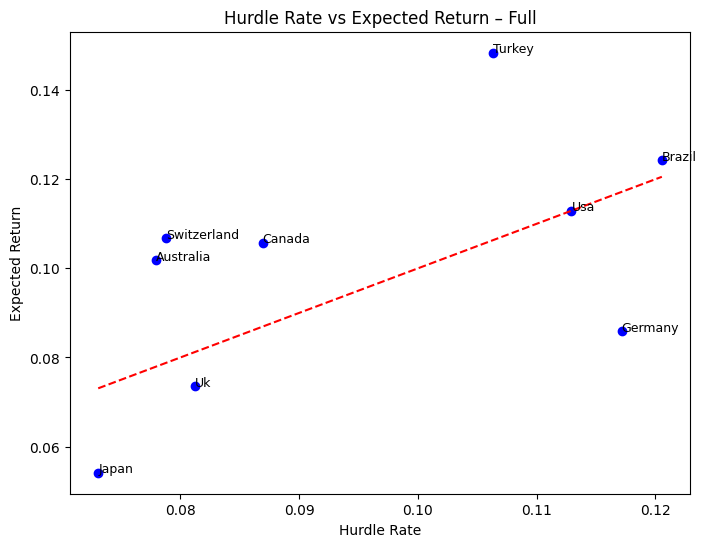

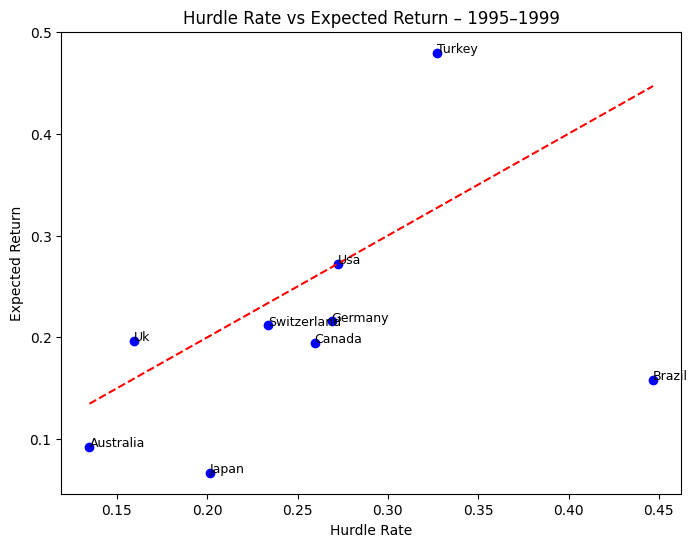

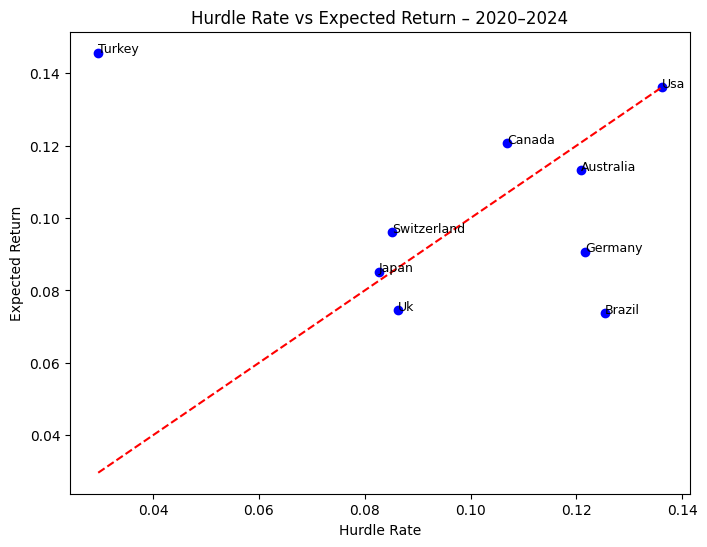

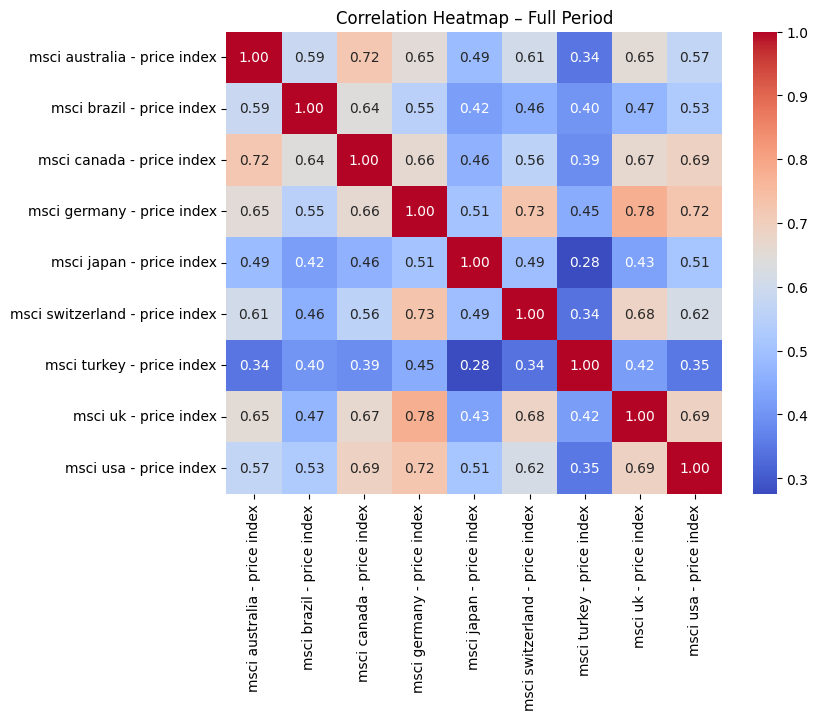

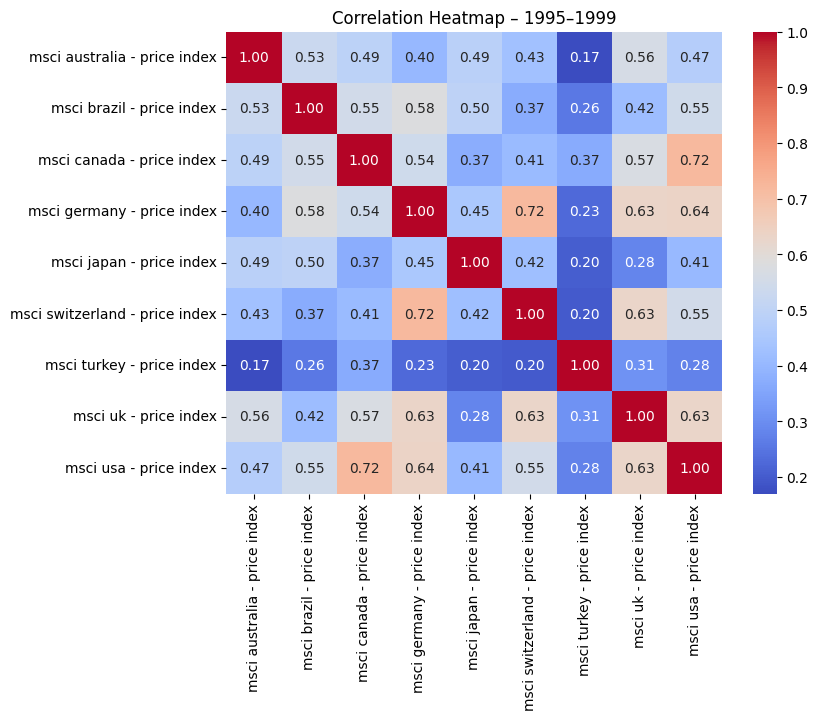

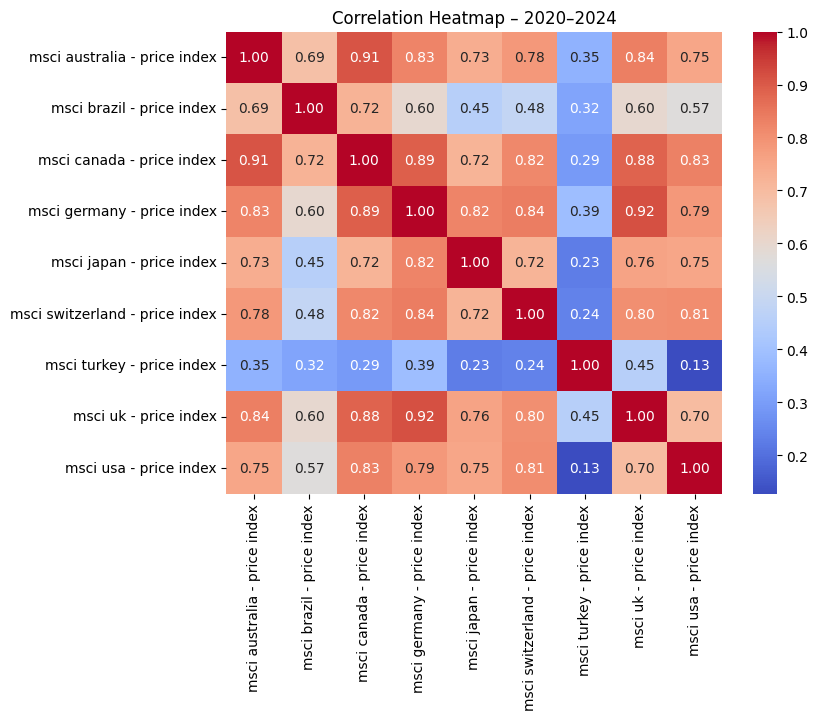

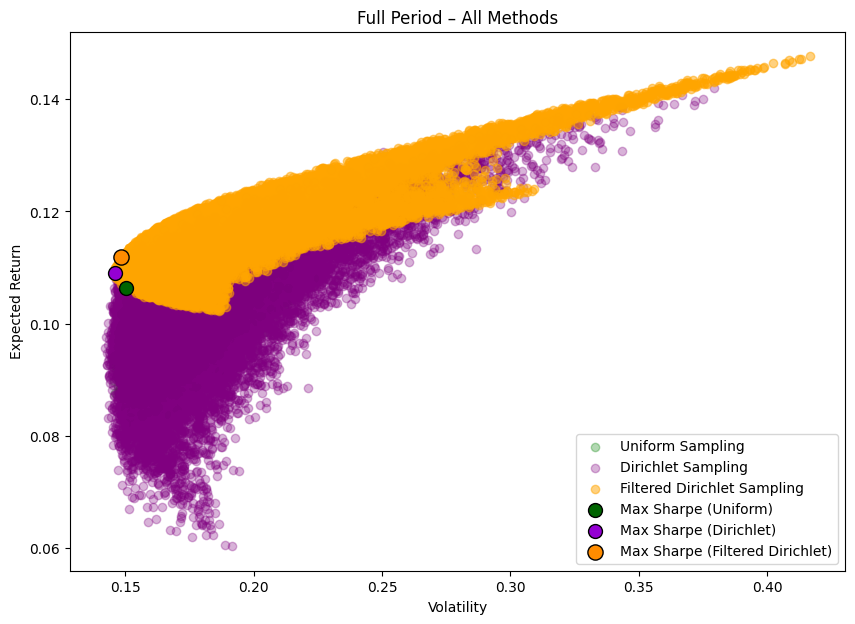

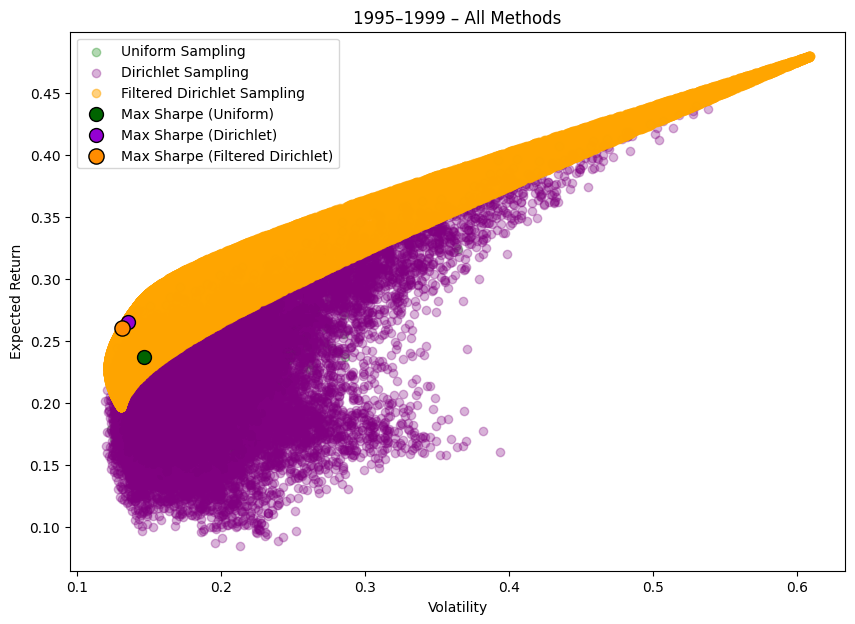

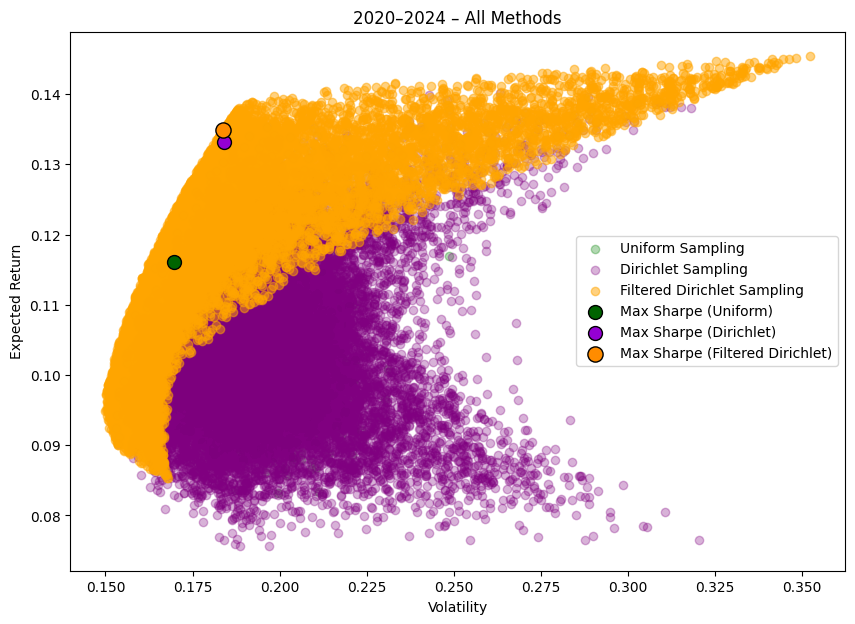

In [ ]:
# === Generating extra visualisations for the report ===

def plot_hurdle_vs_return(stats_df, period_label):
    plt.figure(figsize=(8,6))
    exp_ret = stats_df[f"Expected Return ({period_label})"]
    hurdle = stats_df[f"Hurdle rate ({period_label})"]

    plt.scatter(hurdle, exp_ret, c='blue')
    for idx in stats_df.index:
        # Extract country name between "msci" and "-"
        country = idx.replace("msci", "").replace("- price index", "").strip().title()
        plt.text(hurdle[idx], exp_ret[idx], country, fontsize=9)

    # Add 45° line
    plt.plot([min(hurdle), max(hurdle)], [min(hurdle), max(hurdle)], 'r--')
    plt.xlabel("Hurdle Rate")
    plt.ylabel("Expected Return")
    plt.title(f"Hurdle Rate vs Expected Return – {period_label}")
    plt.show()

# Run for each period
plot_hurdle_vs_return(stats_combined, "Full")
plot_hurdle_vs_return(stats_combined, "1995–1999")
plot_hurdle_vs_return(stats_combined, "2020–2024")

import seaborn as sns

def plot_correlation_heatmap(returns_df, title):
    corr = returns_df.corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Correlation Heatmap – {title}")
    plt.show()

plot_correlation_heatmap(final_returns, "Full Period")
plot_correlation_heatmap(returns_subset_historical, "1995–1999")
plot_correlation_heatmap(returns_subset_present, "2020–2024")

def plot_frontier_all(uniform_results, dirichlet_results, filtered_results, title="Efficient Frontier: All Methods"):
    """
    Overlay efficient frontiers for Uniform, Dirichlet, and Filtered Dirichlet sampling.
    """
    plt.figure(figsize=(10, 7))

    # Uniform portfolios
    plt.scatter(
        uniform_results['vol_arr'], uniform_results['ret_arr'],
        c='green', alpha=0.3, label='Uniform Sampling'
    )

    # Dirichlet portfolios
    plt.scatter(
        dirichlet_results['vol_arr'], dirichlet_results['ret_arr'],
        c='purple', alpha=0.3, label='Dirichlet Sampling'
    )

    # Filtered Dirichlet portfolios
    plt.scatter(
        filtered_results['vol_arr'], filtered_results['ret_arr'],
        c='orange', alpha=0.5, label='Filtered Dirichlet Sampling'
    )

    # Highlight optimal portfolios
    plt.scatter(uniform_results['vol_0'], uniform_results['ret_0'],
                c='darkgreen', s=100, edgecolor='black', label='Max Sharpe (Uniform)')
    plt.scatter(dirichlet_results['vol_0'], dirichlet_results['ret_0'],
                c='darkviolet', s=100, edgecolor='black', label='Max Sharpe (Dirichlet)')
    plt.scatter(filtered_results['vol_0'], filtered_results['ret_0'],
                c='darkorange', s=120, edgecolor='black', label='Max Sharpe (Filtered Dirichlet)')

    plt.xlabel('Volatility')
    plt.ylabel('Expected Return')
    plt.title(title)
    plt.legend()
    plt.show()

# Generate overlays for all periods
plot_frontier_all(results_full, results_full_dirichlet, results_full_filtered, "Full Period – All Methods")
plot_frontier_all(results_historical, results_historical_dirichlet, results_hist_filtered, "1995–1999 – All Methods")
plot_frontier_all(results_present, results_present_dirichlet, results_recent_filtered, "2020–2024 – All Methods")


/tmp/ipython-input-3-1293454135.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  MSCI_prices = pd.read_csv("/content/MSCI returns.csv", parse_dates=['Date'], thousands=',')
/tmp/ipython-input-3-1293454135.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  MSCI_dividends = pd.read_csv("/content/MSCI dividends.csv", parse_dates=['date'], thousands=',')
/tmp/ipython-input-3-1293454135.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  FX_returns = pd.read_csv("/content/FX returns.csv", parse_dates=['date'], thousands=',')


Indices of FX_returns:             aud to usd (boe) - exchange rate  \
1995-01-01                          0.007757   
1995-02-01                         -0.022815   
1995-03-01                         -0.026778   
1995-04-01                         -0.005283   
1995-05-01                         -0.007212   
1995-06-01                         -0.017113   
1995-07-01                         -0.008167   
1995-08-01                          0.045515   
1995-09-01                          0.009444   
1995-10-01                          0.017308   

            brazilian real to us $ (wmr) - exchange rate  \
1995-01-01                                      0.012397   
1995-02-01                                      0.011343   
1995-03-01                                     -0.017595   
1995-04-01                                     -0.053304   
1995-05-01                                     -0.013691   
1995-06-01                                      0.011634   
1995-07-01                  

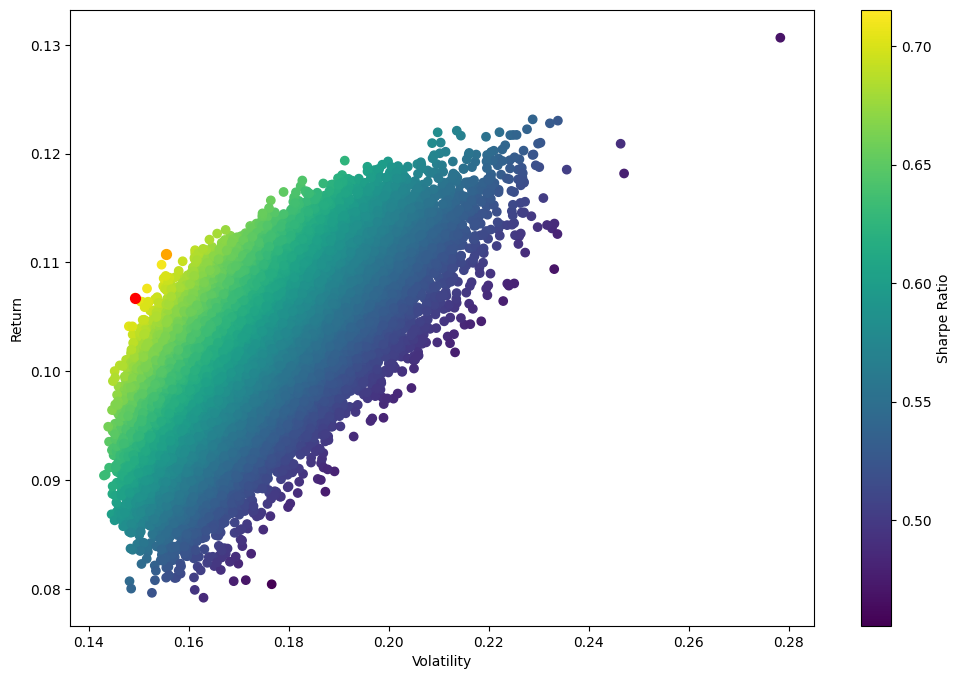

Optimal Portfolio Composition (Maximum Sharpe Ratio assuming zero risk-free rate ):
                            Index    Weight
8          msci usa - price index  0.341131
5  msci switzerland - price index  0.329710
0    msci australia - price index  0.179656
7           msci uk - price index  0.032468
2       msci canada - price index  0.031670
1       msci brazil - price index  0.024321
4        msci japan - price index  0.023523
6       msci turkey - price index  0.023519
3      msci germany - price index  0.014001
Optimal Portfolio Sharpe Ratio: 0.7153
Optimal Portfolio Composition (Maximum Sharpe Ratio assuming 4% risk-free rate ):
                            Index    Weight
8          msci usa - price index  0.305259
5  msci switzerland - price index  0.266787
2       msci canada - price index  0.173092
0    msci australia - price index  0.081900
1       msci brazil - price index  0.070062
6       msci turkey - price index  0.067523
4        msci japan - price index  0.015703
7  

In [ ]:
"""
This exploratory script represents my initial experimentation with portfolio optimization
using MSCI index returns. It uses a simple Monte Carlo approach to simulate random portfolios,
calculate Sharpe ratios (with and without a risk-free rate), and visualize the efficient frontier.
These experiments informed the design and methodology of the final project script.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creating 3 dataframes one for MSCI indexes prices, one for MSCI indexes annualised dividends, and one for FX returns of the corresponding currencies
MSCI_prices = pd.read_csv("/content/MSCI returns.csv", parse_dates=['Date'], thousands=',')
MSCI_dividends = pd.read_csv("/content/MSCI dividends.csv", parse_dates=['date'], thousands=',')
FX_returns = pd.read_csv("/content/FX returns.csv", parse_dates=['date'], thousands=',')

# Slicing the dataframe to get only the desired data
MSCI_prices = MSCI_prices.iloc[:, :10]
MSCI_dividends = MSCI_dividends.iloc[:, :10]
FX_returns = FX_returns.iloc[:, :10]

# Standardizing column names of dataframes
MSCI_prices.columns = MSCI_prices.columns.str.lower()
MSCI_dividends.columns = MSCI_dividends.columns.str.lower()
FX_returns.columns = FX_returns.columns.str.lower()

# Standardizing the format of the dataframes
MSCI_prices['date'] = pd.to_datetime(MSCI_prices['date'], format='%Y.%m')
MSCI_dividends['date'] = pd.to_datetime(MSCI_dividends['date'], format='%Y.%m')
FX_returns['date'] = pd.to_datetime(FX_returns['date'], format='%Y.%m')

# Converting data columns to numeric
MSCI_prices.iloc[:, 1:] = MSCI_prices.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
MSCI_dividends.iloc[:, 1:] = MSCI_dividends.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
FX_returns.iloc[:, 1:] = FX_returns.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# Function to fix October dates
def fix_october_dates(date_series):
    fixed_dates = []
    prev_month = None

    for date in date_series:
        # If the month is January (1), we need to infer if it should be October (10)
        if date.month == 1:
            # If the previous month was September (9), assume it's October (10)
            if prev_month == 9:
                fixed_dates.append(date.replace(month=10))
            else:
                # Otherwise, it's correct as January
                fixed_dates.append(date)
        else:
            # For all other months, keep the date as it is
            fixed_dates.append(date)

        prev_month = date.month  # Update the previous month

    return fixed_dates

# Set Date as the index
MSCI_prices.set_index('date', inplace=True)
MSCI_dividends.set_index('date', inplace=True)
FX_returns.set_index('date', inplace=True)

# Apply the function to fix October dates
MSCI_prices.index = fix_october_dates(MSCI_prices.index)
MSCI_dividends.index = fix_october_dates(MSCI_dividends.index)
FX_returns.index = fix_october_dates(FX_returns.index)

MSCI_dividends.columns = MSCI_prices.columns

# Calculate percentage change for FX rates (FX returns)
FX_returns = FX_returns.shift(+1) / FX_returns -1  # This will create NaNs for the first row
FX_returns = FX_returns.drop(FX_returns.index[0])

# Fix NaN values after pct_change
FX_returns = FX_returns.fillna(0)  # Fill NaNs with 0 or use another method if desired

# Add USD as a column with 0 returns (USD to USD conversion)
FX_returns['USD'] = 0

# Function to calculate local index returns
def calculate_local_returns(prices, dividend_yield):
    monthly_dividend_yield = dividend_yield / 12
    index_return = prices/prices.shift(1) - 1
    total_index_return = index_return + monthly_dividend_yield  # R_{t+1} + y_{t+1}
    return total_index_return.dropna()

# Calculate local returns for all indices
local_returns = {col: calculate_local_returns(MSCI_prices[col], MSCI_dividends[col])
                 for col in MSCI_prices.columns if col in MSCI_dividends.columns}

# Combine into a DataFrame
local_returns_df = pd.DataFrame(local_returns)

FX_returns.columns = local_returns_df.columns

# Calculate USD-denominated returns
final_returns = local_returns_df + FX_returns + (local_returns_df * FX_returns)

# Drop rows with NaN values (if any)
final_returns = final_returns.dropna()

# Display the first few rows of the final USD-denominated returns
print("Indices of USD-denominated returns: ", final_returns[:10])

np.random.seed(42)

num_ports = 100000
all_weights = np.zeros((num_ports, len(final_returns.columns)))  # Use the number of columns in final_total_returns
ret_arr = np.zeros(num_ports)
vol_arr = np.zeros(num_ports)
sharpe_arr = np.zeros(num_ports)
sharpe_arr_non_zero = np.zeros(num_ports)

# Calculate the log returns of the final_total_returns
log_ret = final_returns  # Define log returns

for x in range(num_ports):
    # Generate random weights
    weights = np.random.random(len(final_returns.columns))
    weights = weights / np.sum(weights)

    # Save weights
    all_weights[x, :] = weights

    # Expected return
    ret_arr[x] = np.sum(log_ret.mean() * weights)* 12

    # Expected volatility (annualized)
    vol_arr[x] = np.sqrt(np.dot(weights.T, np.dot(log_ret.cov() * 12, weights)))  # Annualized volatility

    # Sharpe ratio (assuming a risk-free rate of 0)
    sharpe_arr[x] = ret_arr[x] / vol_arr[x]

    # Sharpe ratio (assuming a risk-free rate of 4%)
    sharpe_arr_non_zero[x] = (ret_arr[x] - 0.04) / vol_arr[x]

# Find the index of the maximum Sharpe ratios
max_sr_idx = np.argmax(sharpe_arr)
max_sr_non_zero_idx = np.argmax(sharpe_arr_non_zero)

# Get the corresponding values for volatility and return of the portfolio with the highest Sharpe ratio
max_sr_vol = vol_arr[max_sr_idx]
max_sr_ret = ret_arr[max_sr_idx]

non_zero_max_sr_vol = vol_arr[max_sr_non_zero_idx]
non_zero_max_sr_ret = ret_arr[max_sr_non_zero_idx]

# Plot the efficient frontier
plt.figure(figsize=(12,8))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.scatter(max_sr_vol, max_sr_ret,c='red', s=50)
plt.scatter(non_zero_max_sr_vol, non_zero_max_sr_ret, c='orange', s=50)
plt.show()


# Extract the weights of the portfolio with the highest Sharpe ratio
max_sr_weights = all_weights[max_sr_idx]

max_sr_ratio = sharpe_arr[max_sr_idx]

max_sr_weights_non_zero = all_weights[max_sr_non_zero_idx]

max_sr_ratio_non_zero = sharpe_arr_non_zero[max_sr_non_zero_idx]

# Create a DataFrame to show the weights of the optimal portfolio assuming zero Rf
optimal_portfolio = pd.DataFrame({
    'Index': final_returns.columns,
    'Weight': max_sr_weights
})

# Sort the portfolio by the weights to display them in descending order of importance (0 Rf)
optimal_portfolio = optimal_portfolio.sort_values(by='Weight', ascending=False)

# Print the optimal portfolio composition (0 Rf)
print("Optimal Portfolio Composition (Maximum Sharpe Ratio assuming zero risk-free rate ):")
print(optimal_portfolio)
print(f"Optimal Portfolio Sharpe Ratio: {max_sr_ratio:.4f}")

# Create a DataFrame to show the weights of the optimal portfolio assuming 4% Rf
optimal_portfolio_non_zero_Rf = pd.DataFrame({
    'Index': final_returns.columns,
    'Weight': max_sr_weights_non_zero
})

# Sort the portfolio by the weights to display them in descending order of importance (4% Rf)
optimal_portfolio = optimal_portfolio_non_zero_Rf.sort_values(by='Weight', ascending=False)

# Print the optimal portfolio composition (4% Rf)
print("Optimal Portfolio Composition (Maximum Sharpe Ratio assuming 4% risk-free rate ):")
print(optimal_portfolio)
print(f"Optimal Portfolio Sharpe Ratio: {max_sr_ratio_non_zero:.4f}")


us_returns = final_returns['msci usa - price index']
expected_return = us_returns.mean() * 12
volatility = us_returns.std() * np.sqrt(12)
sharpe_ratio = expected_return / volatility # again assuming zero risk-free rate
sharpe_ratio_non_zero = (expected_return - 0.04) / volatility


print(f"Expected Return (Annualized) for U.S.-Based Asset: {expected_return:.4f}")
print(f"Volatility (Annualized) for U.S.-Based Asset: {volatility:.4f}\n")
print(f"Sharpe Ratio for U.S.-Based Asset (assuming zero risk-free rate): {sharpe_ratio:.4f}")
print(f"Sharpe Ratio for optimal portfolio (assuming zero risk-free rate): {max_sr_ratio:.4f}\n")
print(f"Sharpe Ratio for U.S.-Based Asset (assuming 4% risk-free rate): {sharpe_ratio_non_zero:.4f}")
print(f"Sharpe Ratio for optimal portfolio (assuming 4% risk-free rate): {max_sr_ratio_non_zero:.4f}")
